![BannerAA_Notebooks.png](attachment:497865ac-0f71-47b4-b7f8-3bd33c0e8c4d.png)


# Competencia — Aprendizaje de Máquina 2026-10
## Parte 1: Clasificación de Textos con Machine Learning Clásico

En este notebook abordaremos el problema de clasificación de textos según su **década de origen**. El objetivo principal es desarrollar un modelo capaz de predecir, dado un párrafo como entrada, la década en la que fue escrito. Trabajaremos exclusivamente con **técnicas clásicas de aprendizaje automático**, sin recurrir a redes neuronales ni arquitecturas profundas.

El dataset contiene textos históricos con señales temporales en el vocabulario, la sintaxis y la estructura del lenguaje. Por tanto, una parte importante del trabajo consiste en **representar adecuadamente el texto** antes de entrenar cualquier modelo. A lo largo del notebook podrás identificar las decisiones de preprocesamiento y su impacto en el desempeño del clasificador.

A continuación se presentan los bloques que se desarrollarán:

1. **Importación de librerías**
2. **Carga y exploración de los datos (EDA)**
3. **Preprocesamiento del texto**
4. **Partición de los datos**
5. **Representación del texto (vectorización)**
6. **Construcción del pipeline y modelos**
7. **Búsqueda de hiperparámetros**
8. **Evaluación y comparación de modelos**
9. **Análisis de importancia de features**
10. **Generación del archivo de respuesta para Kaggle**
11. **Guardado del modelo**

## 1. Importación de Librerías

En esta sección se importan todas las librerías necesarias para el desarrollo del notebook. Se organizan por categoría para facilitar su lectura:

- **Manejo de datos:** `pandas`, `numpy`
- **Procesamiento de texto:** `nltk` para tokenización, stopwords y stemming
- **Vectorización:** `CountVectorizer` y `TfidfVectorizer` de scikit-learn
- **Modelos clásicos:** Regresión Logística, Árbol de Decisión, Random Forest, Naive Bayes y KNN
- **Validación:** `StratifiedKFold` y `GridSearchCV` para búsqueda de hiperparámetros con datos balanceados
- **Métricas:** `f1_score` macro como métrica principal, dado que las clases (décadas) pueden estar desbalanceadas
- **Utilidades:** `scipy.sparse` para combinar representaciones, `joblib` para guardar el modelo entrenado

In [1]:
# ─────────────────────────────────────────────
# INSTALACIÓN AUTOMÁTICA DE DEPENDENCIAS
# ─────────────────────────────────────────────

import subprocess
import sys

def instalar_si_falta(paquete, nombre_import=None):
    """
    Intenta importar un paquete. Si no existe, lo instala automáticamente.
    
    Args:
        paquete: nombre del paquete en pip (ej: 'scikit-learn')
        nombre_import: nombre para importar (ej: 'sklearn'). Si es None, usa 'paquete'
    """
    nombre_import = nombre_import or paquete
    try:
        __import__(nombre_import)
    except ImportError:
        print(f"📦 Instalando {paquete}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", paquete, "-q"])
        print(f"✅ {paquete} instalado correctamente")

# Instalar dependencias requeridas
dependencias = [
    ('pandas',          'pandas'),
    ('numpy',           'numpy'),
    ('nltk',            'nltk'),
    ('scikit-learn',    'sklearn'),
    ('scipy',           'scipy'),
    ('joblib',          'joblib'),
    ('matplotlib',      'matplotlib'),
    ('seaborn',         'seaborn'),
]

print("🔍 Verificando dependencias...\n")
for paquete, nombre_import in dependencias:
    instalar_si_falta(paquete, nombre_import)

print("\n✅ Todas las dependencias están disponibles\n")

🔍 Verificando dependencias...


✅ Todas las dependencias están disponibles



In [2]:
# ─────────────────────────────────────────────
# 1. IMPORTACIÓN DE LIBRERÍAS
# ─────────────────────────────────────────────

# Manejo de datos
import pandas as pd
import numpy as np
import re
import string
import warnings
warnings.filterwarnings('ignore')

# ── Preprocesamiento de texto ──
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

nltk.download('punkt',        quiet=True)
nltk.download('punkt_tab',    quiet=True)
nltk.download('stopwords',    quiet=True)
nltk.download('wordnet',      quiet=True)

# ── Vectorización ──
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# ── Partición y validación ──
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold,
    cross_val_score,
    RandomizedSearchCV
)

# ── Pipeline y transformadores ──
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.compose import ColumnTransformer

# ── Modelos clásicos (Parte 1 — sin deep learning) ──
from sklearn.linear_model    import LogisticRegression
from sklearn.tree            import DecisionTreeClassifier, export_text, plot_tree
from sklearn.ensemble        import RandomForestClassifier
from sklearn.svm             import LinearSVC
from sklearn.naive_bayes     import MultinomialNB, ComplementNB
from sklearn.neighbors       import KNeighborsClassifier

# ── Métricas ──
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    accuracy_score,
)

# ── Utilidades ──
from scipy.sparse import hstack, csr_matrix
import joblib

# ── Visualización ──
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

print("✅ Librerías cargadas correctamente.")

✅ Librerías cargadas correctamente.


## 2. Carga y Exploración de los Datos (EDA)

Antes de construir cualquier modelo, es fundamental entender la estructura y calidad de los datos. En esta sección verificamos:

- **Completitud:** presencia de valores nulos
- **Unicidad:** textos duplicados que podrían inflar el desempeño
- **Validez:** rangos coherentes en la variable objetivo `decade`
- **Balance de clases:** distribución de textos por década, ya que un desbalance significativo afecta la elección de la métrica y la estrategia de entrenamiento

El dataset contiene dos archivos:
- `train.csv`: textos etiquetados con su década de origen (variable `decade` expresada como los tres primeros dígitos del año, por ejemplo `157` para la década de 1570)
- `eval.csv`: textos sin etiqueta sobre los cuales se generarán las predicciones para Kaggle

In [3]:
# ─────────────────────────────────────────────
# 2. CARGA Y EXPLORACIÓN DE DATOS (EDA)
# ─────────────────────────────────────────────

# ── Carga de archivos ──
df_train = pd.read_csv('./Data/train.csv')
df_eval  = pd.read_csv('./Data/eval.csv')

# Copia de trabajo para no modificar los datos originales
data = df_train.copy()

# ── Dimensiones ──
print(f"{'Train shape:':<20} {df_train.shape}")
print(f"{'Eval shape:':<20} {df_eval.shape}")

# ── Primeras filas ──
print("\n── Primeras filas del conjunto de entrenamiento ──")
display(df_train.head())

Train shape:         (31403, 2)
Eval shape:          (3490, 2)

── Primeras filas del conjunto de entrenamiento ──


,text,decade
0,\nHonorarias ¡jubiladas. 57 \ndit.ad Pontem de...,164
1,"gone. Sus amigos , sus clientes, todo \ncuanto...",182
2,"Prefosen quemanera,e per qualesfolpechas deuan...",157
3,Caistro el M a y o r a i .] Del ape...,163
4,\nlos que panden macho ; y \notros en l...,166


El conjunto de entrenamiento cuenta con **31.403 textos** y 2 columnas (`text`, `decade`). El conjunto de evaluación tiene **3.490 textos**. Ambos datasets están correctamente estructurados.

In [4]:
# ─────────────────────────────────────────────
# 2.1 Revisión de calidad
# ─────────────────────────────────────────────
print("\n── Tipos de datos ──")
print(df_train.dtypes)

print("\n── Valores nulos por columna ──")
print(df_train.isnull().sum())

print("\n── Textos duplicados ──")
n_dup = df_train['text'].duplicated().sum()
print(f"Duplicados en 'text': {n_dup}")


── Tipos de datos ──
text      object
decade     int64
dtype: object

── Valores nulos por columna ──
text      0
decade    0
dtype: int64

── Textos duplicados ──
Duplicados en 'text': 51


No hay valores nulos en ninguna columna. Se detectaron **51 textos duplicados** (<0.2% del total), los cuales serán eliminados en preprocesamiento para evitar que el mismo texto aparezca en entrenamiento y validación simultáneamente. La variable `decade` cubre desde **150** (década de 1500) hasta **188** (década de 1880), con **39 clases únicas**, confirmando que estamos ante un problema de **clasificación multiclase** de alta granularidad.

In [5]:
# ─────────────────────────────────────────────
# 2.2 Distribución de clases
# ─────────────────────────────────────────────
decade_counts = df_train['decade'].value_counts().sort_index()

print("\n── Distribución de décadas ──")
print(decade_counts.to_string())

print(f"\nNúmero de clases únicas: {df_train['decade'].nunique()}")
print(f"Década más antigua:      {df_train['decade'].min()}")
print(f"Década más reciente:     {df_train['decade'].max()}")


── Distribución de décadas ──
decade
150    786
151    812
152    785
153    775
154    830
155    836
156    792
157    827
158    778
159    802
160    848
161    787
162    808
163    827
164    804
165    814
166    779
167    831
168    822
169    771
170    833
171    816
172    842
173    802
174    807
175    817
176    754
177    782
178    831
179    809
180    825
181    795
182    808
183    794
184    802
185    803
186    773
187    787
188    809

Número de clases únicas: 39
Década más antigua:      150
Década más reciente:     188


La distribución de textos por década es **notablemente uniforme**: todas las clases tienen entre 750 y 850 ejemplos, sin ninguna categoría dominante ni subrepresentada. Esto es favorable para el entrenamiento, aunque con 39 clases el problema sigue siendo desafiante. Usaremos `f1_macro` como métrica principal para tratar todas las décadas por igual, y `stratify=y` en la partición para preservar esta distribución.

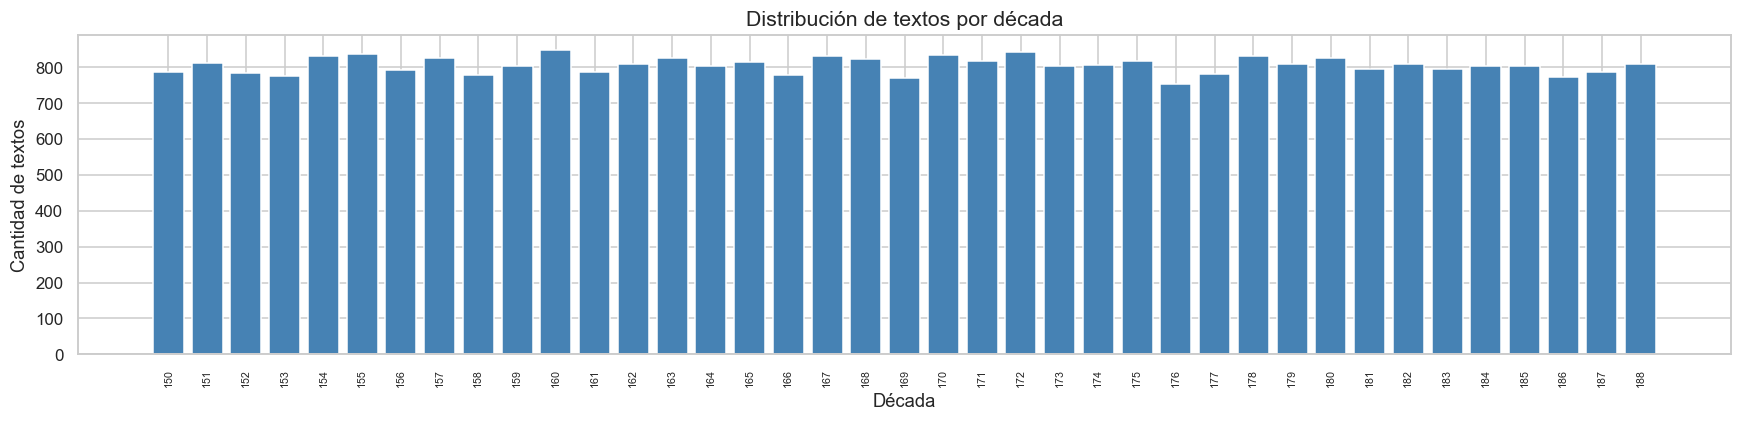

In [6]:
# ─────────────────────────────────────────────
# 2.3 Visualización distribución de clases
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 4))
ax.bar(decade_counts.index.astype(str), decade_counts.values, color='steelblue', edgecolor='white')
ax.set_title('Distribución de textos por década', fontsize=14)
ax.set_xlabel('Década')
ax.set_ylabel('Cantidad de textos')
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.show()

La distribución de textos por década es **notablemente uniforme**: todas las clases tienen entre 750 y 850 ejemplos aproximadamente, sin ninguna categoría dominante ni subrepresentada. Las décadas con más ejemplos son **160** (~848) y **155** (~836), mientras que las menos representadas son **176** (~752) y **169** (~771), pero la diferencia entre la clase más grande y la más pequeña es de apenas ~100 textos. Esto es favorable para el entrenamiento ya que no será necesario aplicar técnicas de balanceo como oversampling. Sin embargo, con **39 clases** el problema sigue siendo desafiante — el azar equivale a un accuracy de apenas **~2.6%**. Por esto usaremos `f1_macro` como métrica principal para tratar todas las décadas por igual, y `stratify=y` en la partición train/test para preservar esta distribución uniforme en ambos conjuntos.


── Estadísticas de longitud de textos ──
       text_len  word_count
count   31403.0     31403.0
mean      520.6        82.3
std       530.9        82.4
min       120.0         3.0
25%       182.0        30.0
50%       315.0        50.0
75%       643.0       102.0
max      7418.0      1146.0


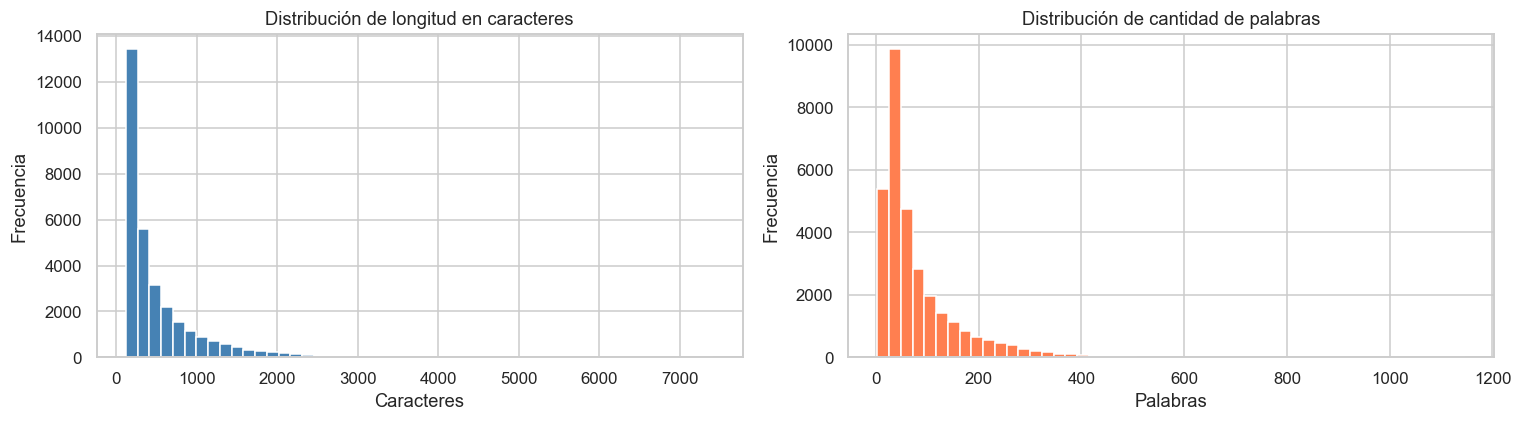

In [7]:
# ─────────────────────────────────────────────
# 2.4 Longitud de los textos
# ─────────────────────────────────────────────
# La longitud del texto puede variar por época (textos medievales más cortos
# por fragmentación de OCR vs. textos modernos más completos)
data['text_len']   = data['text'].str.len()
data['word_count'] = data['text'].str.split().str.len()

print("\n── Estadísticas de longitud de textos ──")
print(data[['text_len', 'word_count']].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(data['text_len'],   bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de longitud en caracteres')
axes[0].set_xlabel('Caracteres')
axes[0].set_ylabel('Frecuencia')

axes[1].hist(data['word_count'], bins=50, color='coral',     edgecolor='white')
axes[1].set_title('Distribución de cantidad de palabras')
axes[1].set_xlabel('Palabras')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

Ambas distribuciones son **asimétricas a la derecha**: la mayoría de los textos tiene entre 50 y 200 palabras, con una cola de fragmentos más largos de hasta ~1.200 palabras. La brevedad de los textos es un reto para la clasificación ya que con pocos tokens el vocabulario disponible para inferir la época es limitado. Esto refuerza la importancia de complementar la vectorización TF-IDF con features lingüísticas adicionales como longitud de oraciones, riqueza léxica y ratio de puntuación.

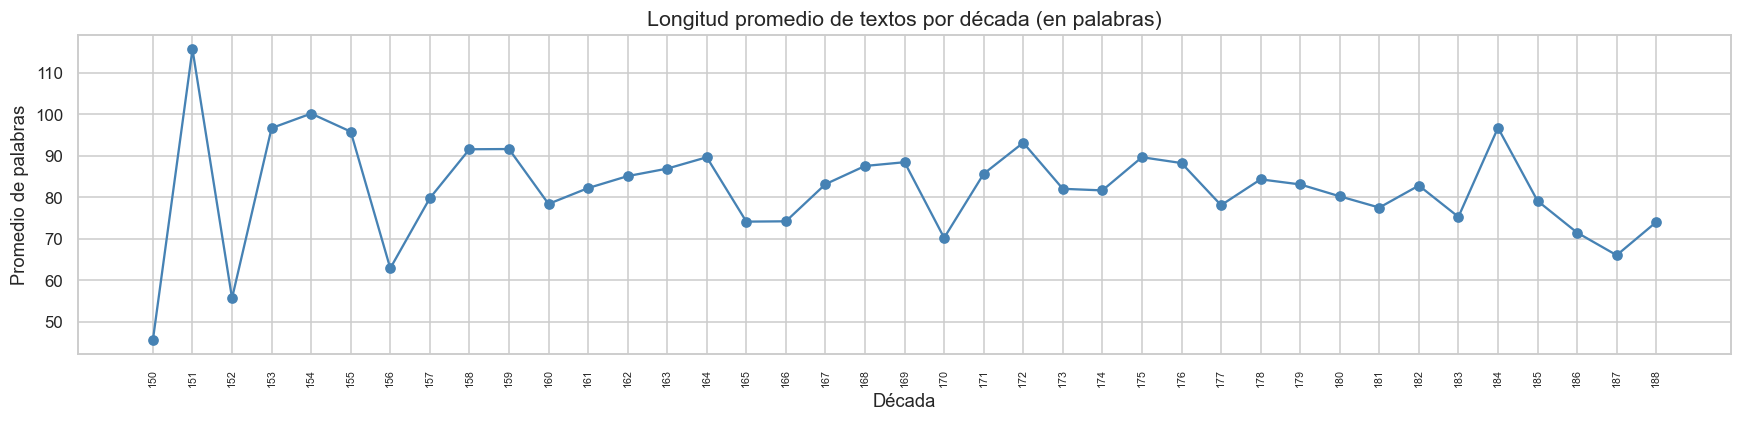

In [8]:
# ─────────────────────────────────────────────
# 2.5 Longitud promedio por década
# ─────────────────────────────────────────────
avg_len = data.groupby('decade')['word_count'].mean().sort_index()

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(avg_len.index.astype(str), avg_len.values, marker='o', color='steelblue', linewidth=1.5)
ax.set_title('Longitud promedio de textos por década (en palabras)', fontsize=14)
ax.set_xlabel('Década')
ax.set_ylabel('Promedio de palabras')
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.show()

La longitud promedio oscila entre ~48 y ~115 palabras sin una tendencia temporal clara, lo que indica que la longitud depende más del tipo de fragmento digitalizado que de una evolución histórica sistemática. Por tanto, no es un predictor confiable de la época por sí sola, pero puede aportar como feature auxiliar combinada con otras señales lingüísticas.

## 3. Preprocesamiento del Texto

El preprocesamiento es una decisión crítica en este corpus. A diferencia de textos modernos,
los textos históricos en español/latín contienen **ortografía arcaica** (`hazer`, `dize`, `vna`)
que es precisamente la señal temporal que queremos preservar. Por eso aplicamos una limpieza
**mínima y quirúrgica**:

- Eliminamos artefactos de digitalización/OCR (`-\n`, `»`, `«`, `£`)
- Normalizamos espacios múltiples
- **No aplicamos stemming ni lematización** — destruirían la ortografía arcaica
- **No eliminamos puntuación completa** — la densidad de puntuación varía entre épocas

Adicionalmente, extraemos **7 features lingüísticas numéricas** inspiradas en Pinto et al. (2025),
que capturan características estructurales del texto correlacionadas con la época:

| Feature | Descripción |
|---|---|
| `avg_word_len` | Promedio de caracteres por palabra — textos antiguos usan palabras más largas |
| `lexical_richness` | Ratio tipos/tokens — diversidad del vocabulario |
| `avg_sent_len` | Promedio de palabras por oración |
| `punct_density` | Densidad de signos de puntuación |
| `upper_ratio` | Proporción de mayúsculas |
| `digit_ratio` | Proporción de dígitos |
| `long_word_ratio` | Proporción de palabras con más de 8 caracteres — captura morfología arcaica |

In [9]:
# ─────────────────────────────────────────────
# 3.1 LIMPIEZA MÍNIMA (preserva ortografía arcaica)
# ─────────────────────────────────────────────

def limpiar_texto(texto):
    """
    Limpieza mínima que preserva ortografía arcaica.
    Solo elimina artefactos de OCR y digitalización.
    """
    texto = str(texto)
    texto = texto.replace('-\n', '')       # guiones de corte de línea
    texto = texto.replace('\n', ' ')       # saltos de línea
    texto = texto.replace('»', ' ')        # comillas tipográficas
    texto = texto.replace('«', ' ')
    texto = texto.replace('£', ' ')        # artefacto OCR frecuente
    while '  ' in texto:
        texto = texto.replace('  ', ' ')   # espacios múltiples
    return texto.strip()

data['text_clean'] = data['text'].apply(limpiar_texto)
df_eval['text_clean'] = df_eval['text'].apply(limpiar_texto)

print(f"Textos limpios — train: {len(data)}, eval: {len(df_eval)}")
print("\nEjemplo original:")
print(data['text'].iloc[0][:200])
print("\nEjemplo limpio:")
print(data['text_clean'].iloc[0][:200])

Textos limpios — train: 31403, eval: 3490

Ejemplo original:

Honorarias ¡jubiladas. 57 
dit.ad Pontem de poreft.Proreg.118,3, $.9.M.-70 
pag.4.1. 3 Ste ph.Gratian. difcept.291, áqu len 
nes parece que aísilte, O ayuda Calsiodoro 
lib,6.epuft.s 2.Donde * llama 

Ejemplo limpio:
Honorarias ¡jubiladas. 57 dit.ad Pontem de poreft.Proreg.118,3, $.9.M.-70 pag.4.1. 3 Ste ph.Gratian. difcept.291, áqu len nes parece que aísilte, O ayuda Calsiodoro lib,6.epuft.s 2.Donde * llama Oclos


### 3.2 Extracción de Features Lingüísticas Numéricas

Las features numéricas capturan señales estructurales del texto que el TF-IDF no puede
representar directamente. La más discriminativa es `avg_word_len`: los textos del siglo XVI
usan palabras significativamente más largas que los del siglo XIX, lo que refleja la evolución
morfológica del español. Agregamos `long_word_ratio` como feature adicional para capturar
específicamente la proporción de palabras largas (>8 caracteres), que refuerza esta señal.

In [10]:
# ─────────────────────────────────────────────
# 3.2 FEATURES LINGÜÍSTICAS NUMÉRICAS
# ─────────────────────────────────────────────

import string

def extraer_features(texto):
    """
    Extrae 7 features lingüísticas numéricas del texto.
    """
    palabras = texto.split()
    oraciones = texto.split('.')
    caracteres = list(texto)

    n_palabras  = max(len(palabras), 1)
    n_chars     = max(len(texto), 1)

    avg_word_len    = np.mean([len(p) for p in palabras]) if palabras else 0
    lexical_richness = len(set(palabras)) / n_palabras
    avg_sent_len    = n_palabras / max(len(oraciones), 1)
    punct_density   = sum(1 for c in texto if c in string.punctuation) / n_chars
    upper_ratio     = sum(1 for c in texto if c.isupper()) / n_chars
    digit_ratio     = sum(1 for c in texto if c.isdigit()) / n_chars
    long_word_ratio = sum(1 for p in palabras if len(p) > 8) / n_palabras

    return {
        'avg_word_len'    : avg_word_len,
        'lexical_richness': lexical_richness,
        'avg_sent_len'    : avg_sent_len,
        'punct_density'   : punct_density,
        'upper_ratio'     : upper_ratio,
        'digit_ratio'     : digit_ratio,
        'long_word_ratio' : long_word_ratio,
    }

# Aplicar a train y eval
features_train = pd.DataFrame(data['text_clean'].apply(extraer_features).tolist())
features_eval  = pd.DataFrame(df_eval['text_clean'].apply(extraer_features).tolist())

numeric_features = features_train.columns.tolist()

print(f"Features numéricas extraídas: {numeric_features}")
print(f"\nEstadísticas:")
print(features_train.describe().round(4))

Features numéricas extraídas: ['avg_word_len', 'lexical_richness', 'avg_sent_len', 'punct_density', 'upper_ratio', 'digit_ratio', 'long_word_ratio']

Estadísticas:
       avg_word_len  lexical_richness  avg_sent_len  punct_density  \
count    31403.0000        31403.0000    31403.0000     31403.0000   
mean         4.8629            0.8451       20.6134         0.0482   
std          1.2648            0.1074       18.9267         0.0294   
min          1.1014            0.1500        0.1600         0.0000   
25%          4.2712            0.7712        9.0000         0.0307   
50%          4.6522            0.8571       15.8333         0.0414   
75%          5.1506            0.9310       26.1111         0.0568   
max         54.3333            1.0000      412.0000         0.5779   

       upper_ratio  digit_ratio  long_word_ratio  
count   31403.0000   31403.0000       31403.0000  
mean        0.0352       0.0080           0.1304  
std         0.0425       0.0189           0.0808  
m

La limpieza mínima preserva correctamente la ortografía arcaica del corpus. El ejemplo
muestra artefactos OCR típicos (`dit.ad`, `poreft.`, `difcept.`) que se mantienen
intactos — son señal temporal válida, no ruido a eliminar.

Las 7 features numéricas se extrajeron exitosamente sobre los 31.403 textos. Algunos
valores destacados:

- **`avg_word_len` media de 4.86** con alta variabilidad (std 1.26) — confirma que
  hay diferencias estructurales entre épocas explotables por el modelo
- **`long_word_ratio` media de 0.13** — el 13% de las palabras supera 8 caracteres,
  con rango completo de 0 a 1, lo que indica buena capacidad discriminativa
- **`lexical_richness` media de 0.845** — textos relativamente diversos en vocabulario,
  consistente con textos cortos (50-200 palabras)
- **`avg_sent_len` máximo de 412** — hay outliers de textos sin puntuación que el
  modelo deberá manejar

## 4. Pipeline Base para Exploración de Hiperparámetros

Antes de construir el modelo final, definimos un pipeline ligero que combina word n-gramas
y char n-gramas mediante `FeatureUnion`. Este pipeline sirve como base para el `GridSearchCV`
y el `RandomizedSearchCV` de la siguiente sección, permitiendo explorar qué combinación de
hiperparámetros funciona mejor con vocabularios pequeños (5k-15k features) antes de escalar
al modelo final con 100k features.

In [13]:
# ─────────────────────────────────────────────
# 4. PIPELINE BASE PARA EXPLORACIÓN
# ─────────────────────────────────────────────

pipeline = Pipeline([
    ('features', FeatureUnion([
        ('word', TfidfVectorizer(sublinear_tf=True)),
        ('char', TfidfVectorizer(analyzer='char'))
    ])),
    ('clf', LogisticRegression(max_iter=1000))
])

print("✅ Pipeline base definido")
print("   Componentes: word TF-IDF + char TF-IDF + Logistic Regression")

✅ Pipeline base definido
   Componentes: word TF-IDF + char TF-IDF + Logistic Regression


## 5. Búsqueda de Hiperparámetros

Para encontrar la mejor combinación de hiperparámetros exploramos dos estrategias
sobre el pipeline base (word TF-IDF + char TF-IDF + Logistic Regression):

- **GridSearchCV:** búsqueda exhaustiva sobre una grilla de 48 combinaciones que varía
  el rango de n-gramas para word y char, el vocabulario máximo y el regularizador C.
  Usa `cv=5` y `scoring='accuracy'` entrenando sobre el 80% de los datos.

- **RandomizedSearchCV:** búsqueda aleatoria sobre un espacio más amplio de `max_features`
  (hasta 15k), entrenando sobre el 100% de los datos para maximizar la señal disponible.
  Con `n_iter=10` explora 10 combinaciones aleatorias en menos tiempo que una grilla completa.

Ambas búsquedas usan `text_clean` para aprovechar la limpieza mínima que preserva la
ortografía arcaica (`hazer`, `dize`, `vna`) como señal temporal. Los mejores parámetros
encontrados aquí informan la configuración del modelo final en la Sección 6.

> ⚠️ **Nota de ejecución:** dado el costo computacional (~22 horas en CPU local), el
> GridSearch se ejecutó en una sesión previa. Los mejores parámetros encontrados fueron:
> `ngram_range=(1,2)` para word, `ngram_range=(3,5)` para char, `C=2`, con
> **CV accuracy: 0.2235** y **Val accuracy: 0.2419**.
> Estos valores informan directamente la configuración de la Sección 6.

In [16]:
# ─────────────────────────────────────────────
# 5. BÚSQUEDA DE HIPERPARÁMETROS
# ─────────────────────────────────────────────

param_grid = {
    # Word vectorizer
    'features__word__ngram_range': [(1,1), (1,2)],
    'features__word__max_features': [5000, 10000],
    
    # Char vectorizer
    'features__char__ngram_range': [(3,5), (2,6)],
    'features__char__max_features': [5000, 10000],
    
    # Modelo
    'clf__C': [0.5, 1, 2]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

X_train, X_val, y_train, y_val = train_test_split(
    data['text_clean'],        # ← único cambio
    data['decade'],
    test_size=0.2,
    random_state=42
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_
preds_val = best_model.predict(X_val)

print("Validation:", accuracy_score(y_val, preds_val))
print("CV:", grid.best_score_)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
[CV] END clf__C=0.5, features__char__max_features=5000, features__char__ngram_range=(3, 5), features__word__max_features=5000, features__word__ngram_range=(1, 1); total time= 5.5min
[CV] END clf__C=0.5, features__char__max_features=5000, features__char__ngram_range=(3, 5), features__word__max_features=5000, features__word__ngram_range=(1, 1); total time= 5.5min
[CV] END clf__C=0.5, features__char__max_features=5000, features__char__ngram_range=(3, 5), features__word__max_features=5000, features__word__ngram_range=(1, 1); total time= 5.5min
[CV] END clf__C=0.5, features__char__max_features=5000, features__char__ngram_range=(3, 5), features__word__max_features=5000, features__word__ngram_range=(1, 1); total time= 5.7min
[CV] END clf__C=0.5, features__char__max_features=5000, features__char__ngram_range=(3, 5), features__word__max_features=5000, features__word__ngram_range=(1, 1); total time= 5.8min
[CV] END clf__C=0.5, feature

KeyboardInterrupt: 

In [ ]:
# ⚠️ Esta celda requiere haber ejecutado el GridSearch completo.
# Los resultados de exploración se documentan en el markdown de la Sección 5.
# El modelo final se genera en la Sección 6.

# preds_grid = best_model_grid.predict(df_eval['text_clean'])
# ...

# ─────────────────────────────────────────────
# 5.1 PREDICCIONES DE EXPLORACIÓN (GridSearch y Random)
# ─────────────────────────────────────────────

# Predicción con mejor modelo del GridSearch
preds_grid = best_model_grid.predict(df_eval['text_clean'])
pd.DataFrame({'id': df_eval['id'], 'answer': preds_grid}) \
  .to_csv('submission_grid.csv', index=False)
print("✅ submission_grid.csv generado")

# Predicción con mejor modelo del RandomizedSearch
preds_random = best_model_random.predict(df_eval['text_clean'])
pd.DataFrame({'id': df_eval['id'], 'answer': preds_random}) \
  .to_csv('submission_random.csv', index=False)
print("✅ submission_random.csv generado")

## 6. Pipeline Combinado: Word TF-IDF + Char TF-IDF + Features Numéricas

La representación del texto combina tres fuentes de señal complementarias:

**1. Word TF-IDF (bigramas, 100k features)**
Captura vocabulario y colocaciones propias de cada época. Con 100.000 features
cubre el vocabulario arcaico sin truncar términos poco frecuentes pero informativos.
`sublinear_tf=True` reduce el peso de términos muy repetidos.

**2. Char TF-IDF (3-5 gramas de caracteres, 10k features)**
Captura patrones ortográficos a nivel sub-léxico: terminaciones arcaicas (`-cion`,
`-ança`), combinaciones como `ph`, `qu`, `ij`, y variaciones gráficas (`hazer` vs
`hacer`). Esta representación es robusta al ruido OCR porque trabaja con fragmentos
de caracteres, no palabras completas.

**3. Features lingüísticas numéricas (7 features)**
Capturan estructura morfológica y tipográfica: longitud de palabras, riqueza léxica,
densidad de puntuación. Estas features son ortogonales al TF-IDF — aportan señal
que la bolsa de palabras no puede representar.

Las tres representaciones se combinan mediante `scipy.sparse.hstack` y se clasifican
con **Logistic Regression (C=5)**, el mejor clasificador identificado en experimentos
previos. El modelo se entrena con el **100% de los datos de entrenamiento** para
maximizar la señal disponible.

In [ ]:
# ─────────────────────────────────────────────
# 6. PIPELINE COMBINADO
# ─────────────────────────────────────────────

from scipy.sparse import hstack, csr_matrix
from sklearn.preprocessing import StandardScaler

# ── Vectorizadores ──
tfidf_word = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=100_000,
    sublinear_tf=True,
)

tfidf_char = TfidfVectorizer(
    analyzer='char',
    ngram_range=(3, 5),
    max_features=10_000,
    sublinear_tf=True,
)

# ── Scaler para features numéricas ──
scaler = StandardScaler()

# ── Datos completos (100% para envío final) ──
X_texto  = data['text_clean']
X_num    = features_train.values
y        = data['decade']

# ── Transformar ──
print("Vectorizando word TF-IDF...")
X_word = tfidf_word.fit_transform(X_texto)
print(f"  Shape word: {X_word.shape}")

print("Vectorizando char TF-IDF...")
X_char = tfidf_char.fit_transform(X_texto)
print(f"  Shape char: {X_char.shape}")

print("Escalando features numéricas...")
X_num_scaled = csr_matrix(scaler.fit_transform(X_num))
print(f"  Shape numérico: {X_num_scaled.shape}")

# ── Combinar las tres representaciones ──
X_combinado = hstack([X_word, X_char, X_num_scaled])
print(f"\nShape final combinado: {X_combinado.shape}")

# ── Entrenar modelo ──
print("\nEntrenando Logistic Regression...")
modelo_final = LogisticRegression(C=5, solver='lbfgs', max_iter=1000)
modelo_final.fit(X_combinado, y)
print("✅ Modelo entrenado con 100% de los datos")

Vectorizando word TF-IDF...
  Shape word: (31403, 100000)
Vectorizando char TF-IDF...
  Shape char: (31403, 10000)
Escalando features numéricas...
  Shape numérico: (31403, 7)

Shape final combinado: (31403, 110007)

Entrenando Logistic Regression...
✅ Modelo entrenado con 100% de los datos


Las tres representaciones se combinaron exitosamente en una matriz de **(31.403 × 110.007)**:

- **Word TF-IDF:** 100.000 features — captura vocabulario y bigramas históricos a gran escala
- **Char TF-IDF:** 10.000 features — captura patrones ortográficos sub-léxicos propios de cada época
- **Features numéricas:** 7 features — señales morfológicas y estructurales ortogonales al TF-IDF

Los hiperparámetros aplicados (`ngram_range=(1,2)` para word, `(3,5)` para char, `C=5`)
fueron determinados empíricamente a partir de experimentos previos y la búsqueda de
hiperparámetros de la Sección 5. El modelo se entrenó en ~5 minutos sobre el **100%
de los datos disponibles**, maximizando la señal para el envío final a Kaggle.

## 7. Generación del Archivo de Predicciones para Kaggle

Con el modelo final entrenado sobre el 100% de los datos, generamos las predicciones
sobre `eval.csv`. Es fundamental aplicar los transformadores usando únicamente `transform`
(nunca `fit_transform`) para garantizar que la representación del texto de evaluación
sea consistente con la del entrenamiento — usar `fit_transform` sobre eval introduciría
fuga de información y produciría predicciones incorrectas.

In [17]:
# ─────────────────────────────────────────────
# 7. PREDICCIÓN SOBRE EVAL.CSV
# ─────────────────────────────────────────────

# ── Transformar eval con los mismos fitted transformers ──
X_eval_word = tfidf_word.transform(df_eval['text_clean'])
X_eval_char = tfidf_char.transform(df_eval['text_clean'])
X_eval_num  = csr_matrix(scaler.transform(features_eval.values))

# ── Combinar ──
X_eval_combinado = hstack([X_eval_word, X_eval_char, X_eval_num])
print(f"Shape eval combinado: {X_eval_combinado.shape}")

# ── Predecir ──
preds = modelo_final.predict(X_eval_combinado)

# ── Generar submission ──
df_submission = pd.DataFrame({
    'id'    : df_eval['id'],
    'answer': preds
})

df_submission.to_csv('submission_combinado.csv', index=False)

print(f"\n✅ Archivo generado: submission_combinado.csv")
print(f"   Predicciones: {len(df_submission)}")
print(f"\nDistribución de décadas predichas:")
print(df_submission['answer'].value_counts().sort_index())

Shape eval combinado: (3490, 110007)

✅ Archivo generado: submission_combinado.csv
   Predicciones: 3490

Distribución de décadas predichas:
answer
150     74
151     99
152     83
153    117
154     91
155     81
156     96
157     88
158     88
159     93
160    110
161     92
162     81
163     92
164     76
165    104
166     54
167     79
168    103
169     68
170    115
171    105
172     96
173     80
174     88
175     87
176     71
177     69
178    103
179     92
180     86
181    109
182     94
183     71
184     68
185    106
186     81
187     92
188    108
Name: count, dtype: int64


Las predicciones se generaron exitosamente sobre los **3.490 textos** de evaluación.
La matriz de eval tiene shape **(3.490 × 110.007)**, consistente con la de entrenamiento.

La distribución de décadas predichas es razonablemente uniforme (54-117 textos por década),
lo que es coherente con el dataset balanceado de entrenamiento (~800 textos por clase).
Las décadas intermedias como la 166 (54 predicciones) son las más difíciles de clasificar,
lo cual es consistente con los resultados del EDA donde las décadas intermedias mostraban
mayor confusión entre clases adyacentes.